# A tutorial on PyMC

**Day 2, 12:00 — 60 minutes.** Alexander Fengler.

PyMC lets you write a generative model in Python and get a posterior back.
This session builds that from the bottom: what a distribution object *is*,
what a model is made of, what `pm.sample()` actually hands you, and how to
look at it. We finish by writing a regression twice — once by hand, once in
one line with **bambi** — so you can see exactly what the shortcut is doing.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import bambi as bmb
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

RANDOM_SEED = sum(map(ord, "sbi4cogsci-pymc"))
rng = np.random.default_rng(RANDOM_SEED)

print("pymc", pm.__version__, "| arviz", az.__version__, "| bambi", bmb.__version__)

pymc 6.2.0 | arviz 1.2.0 | bambi 0.19.0


::: {.callout-warning}
## Read this before you copy code off the internet
**ArviZ 1.0 (May 2026) was a breaking release.** `az.plot_posterior`,
`az.plot_ppc`, `az.plot_density`, `az.plot_kde` and `az.waic` **no longer
exist**. `az.plot_trace` still exists but now draws *traces only*. The default
credible interval changed from a 94% HDI to an **89% ETI**, so even printed
numbers differ from older material.

Most PyMC tutorials online — including large parts of PyMC's own example
gallery — predate this. If a snippet errors with `AttributeError` on an
`az.plot_*` function, that is why. The pinned `tutorials/uv.lock` guarantees
you are on the versions this notebook was written against.
:::

In [2]:
print("az.plot_posterior exists?", hasattr(az, "plot_posterior"))
print("az.waic exists?          ", hasattr(az, "waic"))
print("use instead: az.plot_dist, az.plot_ppc_dist, az.plot_trace_dist, az.loo")

az.plot_posterior exists? False
az.waic exists?           False
use instead: az.plot_dist, az.plot_ppc_dist, az.plot_trace_dist, az.loo


## 1. What is a PyMC distribution?

This is the piece most tutorials skip, and it is the source of most early
confusion. A PyMC distribution is used in **two different ways**, and they
behave differently.

In [3]:
# (a) Standalone — a distribution object, not attached to anything.
standalone = pm.Normal.dist(mu=0.0, sigma=1.0)
print("type:", type(standalone).__name__)
print("5 draws:", pm.draw(standalone, draws=5, random_seed=RANDOM_SEED).round(3))

type: TensorVariable
5 draws: [-0.241 -0.112 -0.713  0.371  0.275]


`pm.Normal.dist(...)` gives you a *distribution you can draw from*. It has no
name and belongs to no model. Use it whenever you want a distribution as a
value — inside another distribution, as a prior you are inspecting, or just to
simulate.

Now the second way:

In [4]:
# (b) Named, inside a model context — a random VARIABLE in a graph.
with pm.Model() as demo:
    mu = pm.Normal("mu", mu=0.0, sigma=1.0)

print("type:", type(mu).__name__)
print("model variables:", [v.name for v in demo.basic_RVs])

type: TensorVariable
model variables: ['mu']


Inside a `with pm.Model()` block, the same call **registers a node in a
graph**. The name is not decoration — it is the key you will use to get the
posterior back out. Two variables cannot share a name.

Try it outside a model context and PyMC tells you exactly what is wrong:

In [5]:
try:
    oops = pm.Normal("mu", 0.0, 1.0)
except TypeError as e:
    print("TypeError:", e)

TypeError: No model on context stack, which is needed to instantiate distributions. Add variable inside a 'with model:' block, or use the '.dist' syntax for a standalone distribution.


### Densities, not just draws

A distribution also knows its own log-density. This is the quantity every
sampler in this course is actually working with.

logp at 0: -0.9189  (= -0.5*log(2*pi) = -0.9189 )


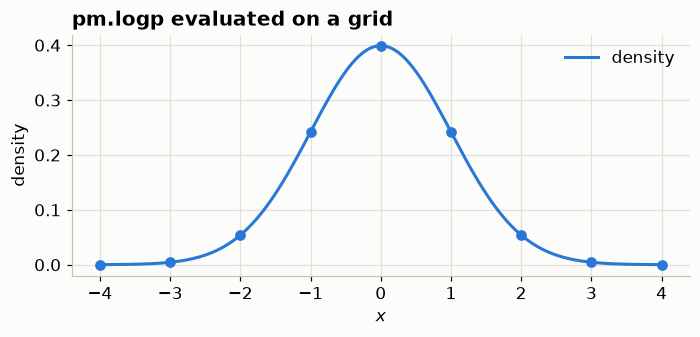

In [6]:
grid = np.linspace(-4, 4, 9)
logp = pm.logp(pm.Normal.dist(0.0, 1.0), grid).eval()

fig, ax = plt.subplots(figsize=(6.5, 3.2))
xs = np.linspace(-4, 4, 300)
ax.plot(xs, np.exp(pm.logp(pm.Normal.dist(0.0, 1.0), xs).eval()),
        color=S.PRIMARY, label="density")
ax.plot(grid, np.exp(logp), "o", color=S.PRIMARY, ms=6, ls="none")
ax.set(title="pm.logp evaluated on a grid", xlabel="$x$", ylabel="density")
ax.legend()
fig.tight_layout()

print("logp at 0:", float(pm.logp(pm.Normal.dist(0.0, 1.0), 0.0).eval()).__round__(4),
      " (= -0.5*log(2*pi) =", round(float(-0.5 * np.log(2 * np.pi)), 4), ")")

> **Poll.** What is the difference between `pm.Normal("x", 0, 1)` and
> `pm.Normal.dist(0, 1)`?
>
> **A.** Nothing; `.dist()` is just shorthand.
> **B.** `.dist()` is faster because it skips validation.
> **C.** The named form registers a variable in the enclosing model; `.dist()`
>   returns a free-standing distribution belonging to no model.
> **D.** `.dist()` can only be used for priors.

<details>
<summary>Answer</summary>

**C.** The named form needs a model context and will raise without one. The
`.dist()` form is a value you can draw from, take the logp of, or nest inside
another distribution — which is exactly how you build custom likelihoods and
mixtures.

</details>

## 2. A first model, and what `pm.sample()` returns

The smallest interesting problem: we observe noisy measurements of an unknown
mean and want the posterior over that mean.

In [7]:
TRUE_MU, TRUE_SIGMA, N = 2.5, 1.5, 60
y_obs = rng.normal(TRUE_MU, TRUE_SIGMA, N)

with pm.Model() as first_model:
    mu = pm.Normal("mu", mu=0.0, sigma=10.0)      # prior
    sigma = pm.HalfNormal("sigma", sigma=5.0)     # prior
    pm.Normal("y", mu=mu, sigma=sigma, observed=y_obs)   # likelihood

    idata = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                      nuts_sampler="pymc", progressbar=False,
                      random_seed=RANDOM_SEED)

print(type(idata))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


<class 'xarray.core.datatree.DataTree'>


::: {.callout-important}
## `pm.sample()` returns an `xarray.DataTree`
In PyMC 6 this is **not** an `arviz.InferenceData` any more. `InferenceData`
still exists as a compatibility shim that warns and hands you a `DataTree`.
The API docstring on the website still says "InferenceData" — the code
disagrees, and the code wins.
:::

A `DataTree` is a tree of labelled groups. Look at what is in it:

In [8]:
print("groups:", list(idata.children))
print()
print(idata["posterior"])

groups: ['posterior', 'sample_stats', 'observed_data']

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:  (chain: 4, draw: 1000)
    Coordinates:
      * chain    (chain) int64 32B 0 1 2 3
      * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
    Data variables:
        mu       (chain, draw) float64 32kB 2.452 2.588 2.308 ... 2.604 2.055 2.186
        sigma    (chain, draw) float64 32kB 1.287 1.298 1.144 ... 1.457 1.212 1.3
    Attributes:
        created_at:                 2026-07-26T04:28:59.577081+00:00
        creation_library:           ArviZ
        creation_library_version:   1.2.0
        creation_library_language:  Python
        inference_library:          pymc
        inference_library_version:  6.2.0
        sample_dims:                ['chain', 'draw']
        sampling_time:              0.37665486335754395
        tuning_steps:               1000


### The gotcha that costs everyone twenty minutes

`idata.posterior` is a **DataTree node**, not a `Dataset`. Most `xarray`
operations you want live on the `Dataset`, so reach through `.dataset`:

In [9]:
print("idata.posterior       ->", type(idata.posterior).__name__)
print("idata.posterior.dataset ->", type(idata.posterior.dataset).__name__)
print("idata.posterior['mu'] ->", type(idata.posterior["mu"]).__name__)
print()

post = idata.posterior.dataset
print("shape (chain, draw):", post["mu"].shape)
print("posterior mean mu = %.3f   (true %.1f)" % (post["mu"].values.mean(), TRUE_MU))
print("posterior mean sigma = %.3f (true %.1f)" % (post["sigma"].values.mean(), TRUE_SIGMA))

idata.posterior       -> DataTree
idata.posterior.dataset -> DatasetView
idata.posterior['mu'] -> DataArray

shape (chain, draw): (4, 1000)
posterior mean mu = 2.497   (true 2.5)
posterior mean sigma = 1.278 (true 1.5)


The `sample_stats` group is where the sampler records what it did. This is
where divergences live — we will lean on it hard on Day 3.

In [10]:
print(sorted(idata["sample_stats"].dataset.data_vars))

['acceptance_rate', 'divergences', 'diverging', 'energy', 'energy_error', 'index_in_trajectory', 'largest_eigval', 'lp', 'max_energy_error', 'n_steps', 'perf_counter_diff', 'perf_counter_start', 'process_time_diff', 'reached_max_treedepth', 'smallest_eigval', 'step_size', 'step_size_bar', 'tree_depth']


## 3. Looking at a posterior with ArviZ 1.x

In [11]:
print(az.summary(idata, kind="stats").to_string())

      mean    sd eti89_lb eti89_ub
mu     2.5  0.17      2.2      2.8
sigma  1.3  0.12      1.1      1.5


Note the interval columns: **89% ETI**, not the 94% HDI you may remember.
You can ask for something else explicitly:

In [12]:
print(az.summary(idata, kind="stats", ci_prob=0.94, ci_kind="hdi").to_string())

      mean    sd hdi94_lb hdi94_ub
mu     2.5  0.17      2.2      2.8
sigma  1.3  0.12      1.1      1.5


The standard first look is `plot_trace_dist` — marginals on the left, traces
on the right.

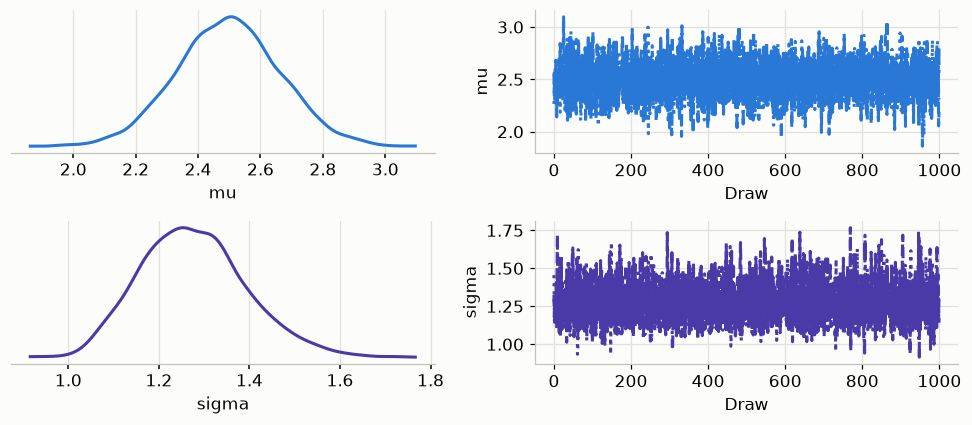

In [13]:
az.plot_trace_dist(idata, combined=True)
plt.gcf().set_size_inches(9, 4)
plt.tight_layout()

And the joint, which we will care about a great deal this afternoon:

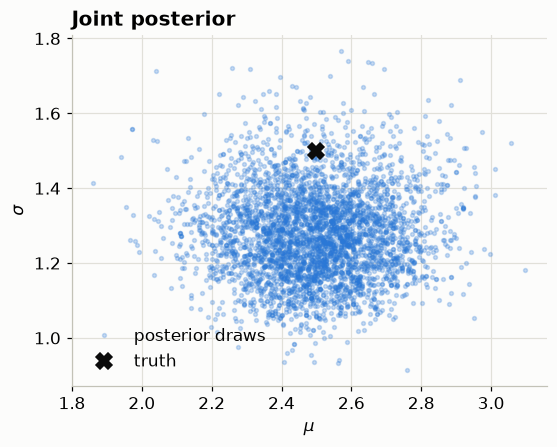

In [14]:
fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.plot(post["mu"].values.ravel(), post["sigma"].values.ravel(), "o",
        color=S.PRIMARY, ms=2.5, alpha=0.25, ls="none", label="posterior draws")
S.truth_point(ax, TRUE_MU, TRUE_SIGMA)
ax.set(title="Joint posterior", xlabel=r"$\mu$", ylabel=r"$\sigma$")
ax.legend()
fig.tight_layout()

`mu` and `sigma` are close to independent here — a round blob. Remember what
this looks like; by 15:00 today you will be looking at one that is not.

### Exercise 1

Re-fit `first_model` with a deliberately bad prior on `mu` — say
`pm.Normal("mu", 20, 0.5)` — and compare the posterior mean to the truth.
How much does 60 data points overcome a confidently wrong prior?

<details>
<summary>Solution</summary>

```python
with pm.Model():
    mu = pm.Normal("mu", 20.0, 0.5)          # confidently wrong
    sigma = pm.HalfNormal("sigma", 5.0)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y_obs)
    bad = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                    nuts_sampler="pymc", progressbar=False,
                    random_seed=RANDOM_SEED)
print(az.summary(bad, kind="stats").to_string())
```

The posterior lands between the prior and the data, much nearer the prior than
you might like — a `sigma=0.5` prior is worth a lot of observations. The
lesson is not "priors are dangerous" but "a prior is a claim, and you should
be able to defend its width as readily as its centre."

</details>

## 4. A regression, by hand

Same machinery, one step up. We simulate a linear relationship and estimate
it.

In [15]:
n = 120
x = rng.normal(0.0, 1.0, n)
TRUE_INTERCEPT, TRUE_SLOPE, TRUE_NOISE = 1.0, 2.0, 0.8
y = TRUE_INTERCEPT + TRUE_SLOPE * x + rng.normal(0.0, TRUE_NOISE, n)
data = pd.DataFrame({"x": x, "y": y})

with pm.Model() as regression:
    intercept = pm.Normal("Intercept", 0.0, 5.0)
    slope = pm.Normal("x", 0.0, 5.0)
    sigma = pm.HalfNormal("sigma", 5.0)
    pm.Normal("y", mu=intercept + slope * data["x"].to_numpy(), sigma=sigma,
              observed=data["y"].to_numpy())

    idata_pymc = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                           nuts_sampler="pymc", progressbar=False,
                           random_seed=RANDOM_SEED)

print(az.summary(idata_pymc, kind="stats").to_string())
print(f"\ntruth: Intercept={TRUE_INTERCEPT}, x={TRUE_SLOPE}, sigma={TRUE_NOISE}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [Intercept, x, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


           mean     sd eti89_lb eti89_ub
Intercept  0.89  0.073     0.78        1
x           1.9  0.074      1.7        2
sigma      0.79  0.052     0.71     0.88

truth: Intercept=1.0, x=2.0, sigma=0.8


Four lines of model, and every line is a modelling decision you made on
purpose. That is the virtue of writing it out.

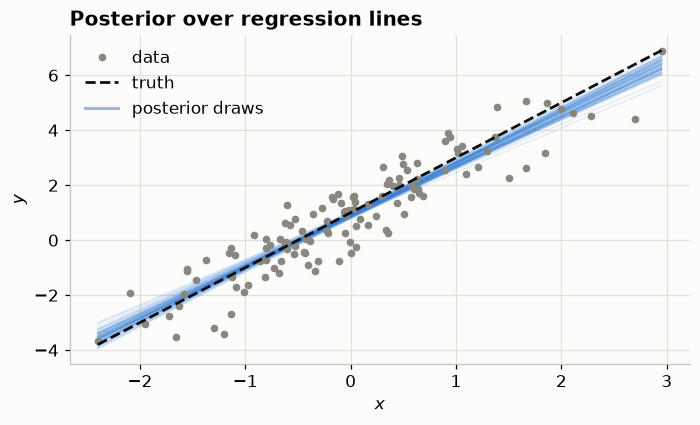

In [16]:
post_p = idata_pymc.posterior.dataset
xs = np.linspace(x.min(), x.max(), 100)
draws = rng.choice(post_p["Intercept"].values.size, 60, replace=False)
ic = post_p["Intercept"].values.ravel()[draws]
sl = post_p["x"].values.ravel()[draws]

fig, ax = plt.subplots(figsize=(6.5, 4))
for i, s in zip(ic, sl):
    ax.plot(xs, i + s * xs, color=S.PRIMARY, alpha=0.12, lw=1)
ax.plot(x, y, "o", color=S.MUTED, ms=4, ls="none", label="data", zorder=3)
ax.plot(xs, TRUE_INTERCEPT + TRUE_SLOPE * xs, "--", color=S.TRUTH, lw=1.8,
        label="truth", zorder=4)
ax.plot([], [], color=S.PRIMARY, alpha=0.5, label="posterior draws")
ax.set(title="Posterior over regression lines", xlabel="$x$", ylabel="$y$")
ax.legend()
fig.tight_layout()

## 5. The same regression, in bambi

For standard regression structures, writing the graph out by hand is
repetitive. **bambi** takes a formula and builds the PyMC model for you.

In [17]:
model_bmb = bmb.Model("y ~ x", data)
print(model_bmb)

       Formula: y ~ x
        Family: gaussian
          Link: mu = identity
  Observations: 120
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.8305, sigma: 5.0922)
            x ~ Normal(mu: 0.0, sigma: 5.0398)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 2.0358)


Notice what `print(model)` gives you: the formula, the family, the link, and
**every prior bambi chose on your behalf**. Those priors are not arbitrary —
they are scaled to your data — but they are choices, and you should look at
them.

In [18]:
idata_bmb = model_bmb.fit(draws=1000, tune=1000, chains=4, cores=1,
                          progressbar=False, random_seed=RANDOM_SEED)
print(az.summary(idata_bmb, kind="stats").to_string())

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [sigma, Intercept, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


           mean     sd eti89_lb eti89_ub
sigma      0.79  0.051     0.71     0.88
Intercept  0.89  0.073     0.78        1
x           1.9  0.073      1.7        2


### There is no magic — look at the generated model

The best way to believe bambi is to make it show you the PyMC model it built.

In [19]:
print(type(model_bmb.backend.model))
for rv in model_bmb.backend.model.basic_RVs:
    print("  ", rv.name)

<class 'pymc.model.core.Model'>
   sigma
   Intercept
   x
   y


That is the same graph you wrote by hand in section 4, with bambi's own
naming. Compare the two side by side:

In [20]:
comparison = pd.DataFrame({
    "hand-written PyMC": az.summary(idata_pymc, kind="stats")["mean"],
    "bambi": az.summary(idata_bmb, kind="stats")["mean"].reindex(
        ["Intercept", "x", "sigma"]),
})
print(comparison.to_string())
print("\n(Small differences are Monte Carlo noise plus bambi's data-scaled priors.)")

          hand-written PyMC bambi
Intercept              0.89  0.89
x                       1.9   1.9
sigma                  0.79  0.79

(Small differences are Monte Carlo noise plus bambi's data-scaled priors.)


### When to use which

| | write it in PyMC | write it in bambi |
|---|---|---|
| standard GLM / mixed model | works, verbose | one line |
| custom likelihood (e.g. a DDM) | the only option | no |
| non-standard structure | the only option | no |
| you want explicit control of every prior | yes | possible, but you are fighting it |

bambi is a front end, not a different engine. Everything you learn about PyMC
sampling, diagnostics and `DataTree` applies unchanged — which is why we did
it in this order.

### Exercise 2

Add a grouping variable to the simulated data (say 5 groups with different
intercepts), then write the bambi formula for a model with a **random
intercept per group**. Fit it and check that the group-level parameters
appear in the posterior.

<details>
<summary>Solution</summary>

```python
g = rng.integers(0, 5, n)
offsets = rng.normal(0, 1.5, 5)
data2 = data.assign(group=[f"g{i}" for i in g],
                    y=data["y"] + offsets[g])

m = bmb.Model("y ~ x + (1|group)", data2)
print(m)
idata2 = m.fit(draws=1000, tune=1000, chains=4, cores=1,
               progressbar=False, random_seed=RANDOM_SEED)
print(az.summary(idata2, kind="stats").to_string())
```

`(1|group)` is a random intercept. You should see `1|group` entries plus a
`1|group_sigma` — the population spread of the group intercepts. That
`_sigma` is the parameter whose geometry we spend all of Day 3, 11:00 on.

</details>

## What to take away

- `pm.Normal.dist(...)` is a distribution; `pm.Normal("name", ...)` inside a
  model context is a **node in a graph**. The name is the key you get results
  back by.
- `pm.sample()` returns an **`xarray.DataTree`**. `idata.posterior` is a tree
  *node* — use `.dataset` when you want Dataset behaviour.
- ArviZ 1.x: `plot_trace_dist`, `plot_dist`, `plot_ppc_dist`, `loo`. The old
  names are gone, and the default interval is 89% ETI.
- Always look at the **joint** posterior, not only the marginals.
- bambi writes the PyMC model for you; `print(model)` shows the priors and
  `model.backend.model` shows the graph. Use it for standard structures, drop
  to PyMC when the likelihood is your own.

Next: we stop assuming the sampler works and start looking at when it does not.